In [12]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
import gc

IMG_SIZE = (64, 64)
NUM_CLASSES = 3

In [13]:
train_ds, val_ds, test_ds = tfds.load(
    "rock_paper_scissors",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)

In [15]:
def get_images_and_labels(dataset, img_size=(64, 64)):
    images = []
    labels = []

    for image, label in dataset:
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 255.0
        images.append(image.numpy())
        labels.append(label.numpy())

    return np.array(images, dtype=np.float32), np.array(labels)

In [16]:
train_images, train_labels = get_images_and_labels(train_ds, IMG_SIZE)
val_images, val_labels = get_images_and_labels(val_ds, IMG_SIZE)
test_images, test_labels = get_images_and_labels(test_ds, IMG_SIZE)

In [17]:
x_train = train_images.reshape(train_images.shape[0], -1)
x_val = val_images.reshape(val_images.shape[0], -1)
x_test = test_images.reshape(test_images.shape[0], -1)

y_train = np.eye(NUM_CLASSES)[train_labels]
y_val = np.eye(NUM_CLASSES)[val_labels]
y_test = np.eye(NUM_CLASSES)[test_labels]

In [18]:
def build_mlp(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64 * 64 * 3,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [19]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.001),
    "SGD_Momentum": tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.001),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

In [20]:
mlp_histories = {}
mlp_results = []

In [24]:
for name, opt in optimizers.items():
    print(f"\nTraining MLP with {name}")

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mlp(opt)

    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=8,
        validation_data=(x_val, y_val),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    mlp_histories[name] = history.history

    mlp_results.append({
        "Model": "MLP",
        "Optimizer": name,
        "Train Loss": history.history["loss"][-1],
        "Train Acc": history.history["accuracy"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Validation Acc": history.history["val_accuracy"][-1],
        "Test Loss": test_loss,
        "Test Acc": test_acc
    })

    del model
    del history
    gc.collect()


Training MLP with SGD
Epoch 1/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4180 - loss: 1.0782 - val_accuracy: 0.5079 - val_loss: 0.9884
Epoch 2/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4881 - loss: 0.9946 - val_accuracy: 0.6944 - val_loss: 0.8354
Epoch 3/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6041 - loss: 0.8782 - val_accuracy: 0.4841 - val_loss: 0.8467
Epoch 4/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6504 - loss: 0.7878 - val_accuracy: 0.8135 - val_loss: 0.6545
Epoch 5/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6993 - loss: 0.7084 - val_accuracy: 0.7540 - val_loss: 0.6597
Epoch 6/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7394 - loss: 0.6497 - val_accuracy: 0.7817 - val_loss: 0.5746
Epoch 7/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7685 - loss: 0.5787 - val_accuracy: 0.8254 - val_loss: 0.4673
Epoch 8/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7985 - loss: 0.

In [25]:
mlp_results_df = pd.DataFrame(mlp_results)
print(mlp_results_df)

  Model     Optimizer  Train Loss  Train Acc  Validation Loss  Validation Acc  \
0   MLP           SGD    0.439952   0.835538         0.524589        0.773810   
1   MLP  SGD_Momentum    1.098977   0.315256         1.098630        0.333333   
2   MLP       Adagrad    0.817168   0.668871         0.718972        0.817460   
3   MLP       RMSProp    1.098862   0.324515         1.098616        0.333333   
4   MLP          Adam    1.098805   0.320547         1.098615        0.333333   

   Test Loss  Test Acc  
0   0.985431  0.413978  
1   1.098630  0.333333  
2   0.916376  0.532258  
3   1.098616  0.333333  
4   1.098675  0.333333  


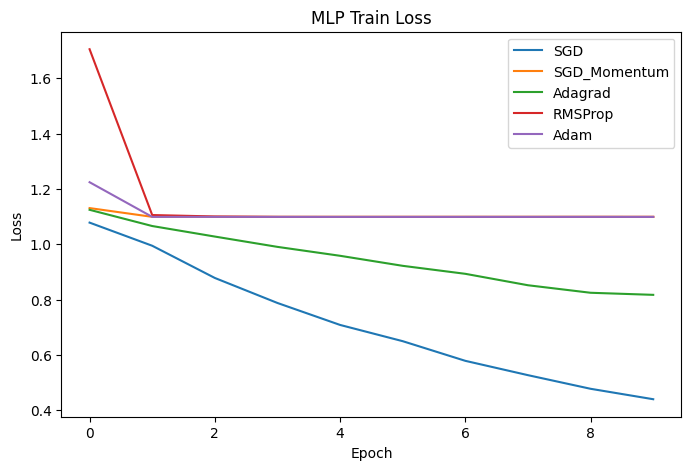

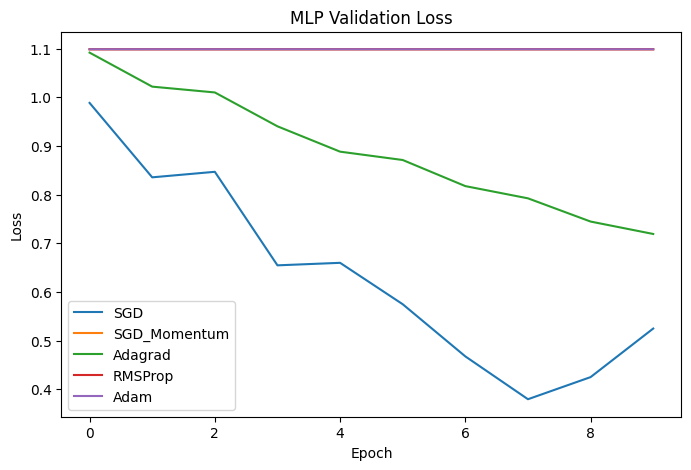

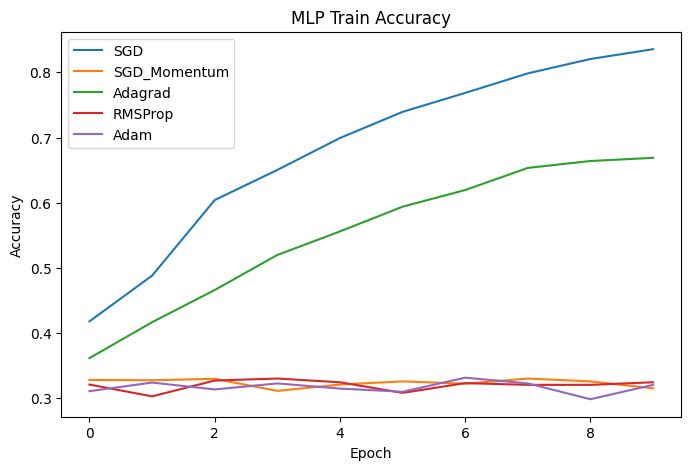

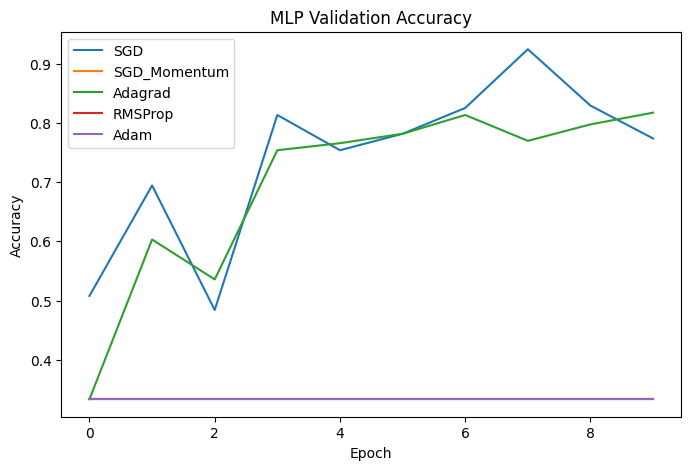

In [26]:
# Figure 1: Train Loss
plt.figure(figsize=(8, 5))
for name in mlp_histories:
    plt.plot(mlp_histories[name]["loss"], label=name)
plt.title("MLP Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Figure 2: Validation Loss
plt.figure(figsize=(8, 5))
for name in mlp_histories:
    plt.plot(mlp_histories[name]["val_loss"], label=name)
plt.title("MLP Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Figure 3: Train Accuracy
plt.figure(figsize=(8, 5))
for name in mlp_histories:
    plt.plot(mlp_histories[name]["accuracy"], label=name)
plt.title("MLP Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Figure 4: Validation Accuracy
plt.figure(figsize=(8, 5))
for name in mlp_histories:
    plt.plot(mlp_histories[name]["val_accuracy"], label=name)
plt.title("MLP Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

In [2]:
train_ds, val_ds, test_ds = tfds.load(
    "rock_paper_scissors",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.YVD2JF_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.YVD2JF_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


In [3]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3
BATCH_SIZE = 16
EPOCHS = 10

In [4]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
def build_cnn(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [6]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.001),
    "SGD_Momentum": tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.001),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

In [8]:
cnn_histories = {}
cnn_results = []

for name, opt in optimizers.items():
    print(f"\nTraining CNN with {name}")

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_cnn(opt)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    cnn_histories[name] = history.history
    cnn_results.append({
        "Model": "CNN",
        "Optimizer": name,
        "Train Loss": history.history["loss"][-1],
        "Train Acc": history.history["accuracy"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Validation Acc": history.history["val_accuracy"][-1],
        "Test Loss": test_loss,
        "Test Acc": test_acc
    })

    del model
    del history
    gc.collect()


Training CNN with SGD
Epoch 1/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 96s 643ms/step - accuracy: 0.3955 - loss: 1.0866 - val_accuracy: 0.4960 - val_loss: 1.0692
Epoch 2/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 88s 614ms/step - accuracy: 0.4806 - loss: 1.0540 - val_accuracy: 0.5198 - val_loss: 1.0412
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 88s 616ms/step - accuracy: 0.5256 - loss: 1.0162 - val_accuracy: 0.5794 - val_loss: 0.9995
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 144s 632ms/step - accuracy: 0.5600 - loss: 0.9647 - val_accuracy: 0.6111 - val_loss: 0.9439
Epoch 5/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 139s 608ms/step - accuracy: 0.6027 - loss: 0.9068 - val_accuracy: 0.6865 - val_loss: 0.8767
Epoch 6/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 141s 603ms/step - accuracy: 0.6332 - loss: 0.8481 - val_accuracy: 0.4960 - val_loss: 0.9230
Epoch 7/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 142s 603ms/step - accuracy: 0.6746 - loss: 0.7724 - val_accuracy: 0.4841 - val_loss: 0.8793
Epoch 8/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 146s 631ms/step 

In [9]:
cnn_results_df = pd.DataFrame(cnn_results)
print(cnn_results_df)

  Model     Optimizer  Train Loss  Train Acc  Validation Loss  Validation Acc  \
0   CNN           SGD    0.564752   0.775132     6.411957e-01        0.674603   
1   CNN  SGD_Momentum    0.008145   0.999118     4.468681e-03        1.000000   
2   CNN       Adagrad    0.192819   0.952822     2.111402e-01        0.916667   
3   CNN       RMSProp    0.000040   1.000000     4.730527e-10        1.000000   
4   CNN          Adam    0.000067   1.000000     1.928266e-05        1.000000   

   Test Loss  Test Acc  
0   0.967143  0.435484  
1   0.751983  0.755376  
2   0.564135  0.803763  
3   0.583766  0.884409  
4   2.221024  0.833333  


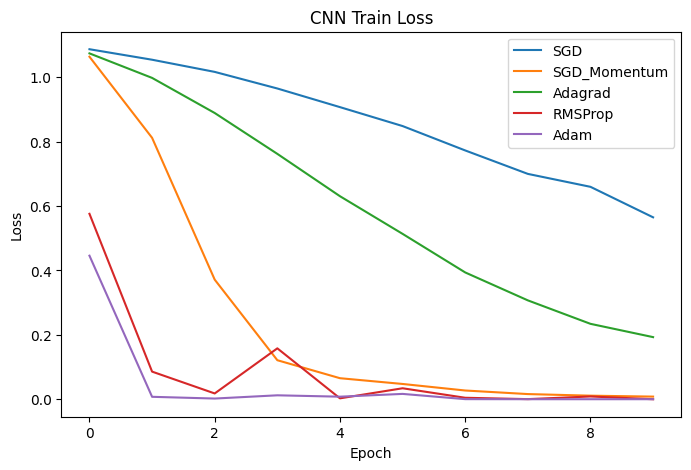

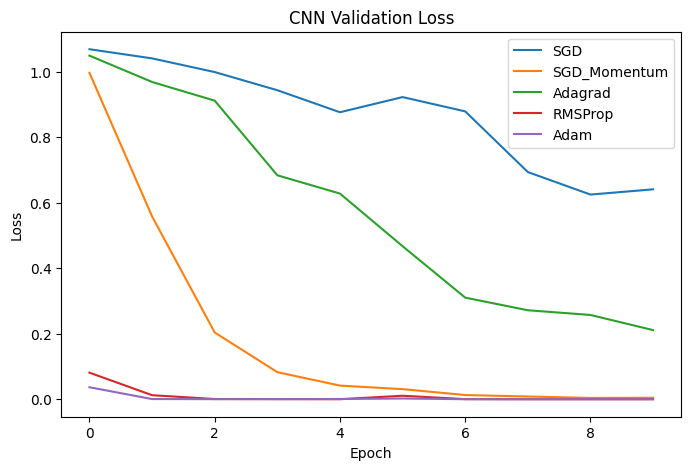

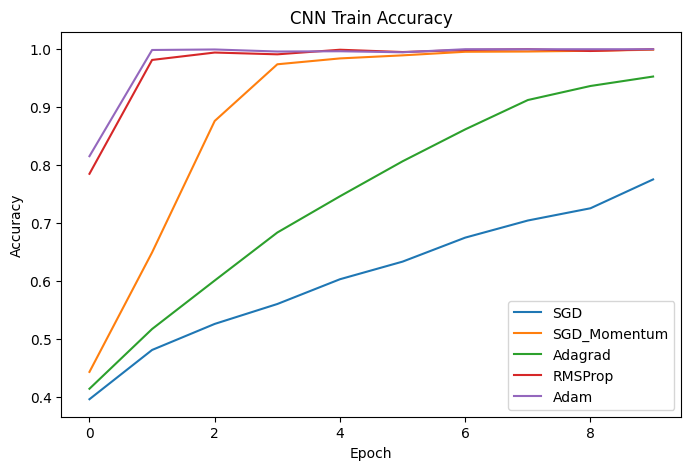

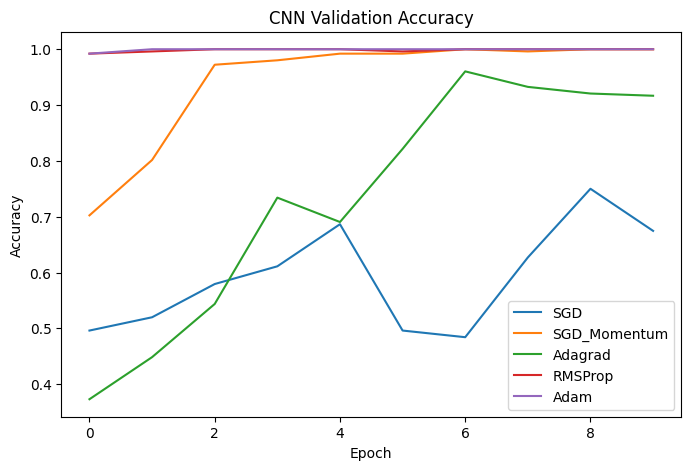

In [10]:
# Figure 1: Train Loss
plt.figure(figsize=(8, 5))
for name in cnn_histories:
    plt.plot(cnn_histories[name]["loss"], label=name)
plt.title("CNN Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Figure 2: Validation Loss
plt.figure(figsize=(8, 5))
for name in cnn_histories:
    plt.plot(cnn_histories[name]["val_loss"], label=name)
plt.title("CNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Figure 3: Train Accuracy
plt.figure(figsize=(8, 5))
for name in cnn_histories:
    plt.plot(cnn_histories[name]["accuracy"], label=name)
plt.title("CNN Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Figure 4: Validation Accuracy
plt.figure(figsize=(8, 5))
for name in cnn_histories:
    plt.plot(cnn_histories[name]["val_accuracy"], label=name)
plt.title("CNN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
mlp_results_df = pd.DataFrame(mlp_results)
final_results_df = pd.concat([mlp_results_df, cnn_results_df], ignore_index=True)
print(final_results_df)

  Model     Optimizer  Train Loss  Train Acc  Validation Loss  Validation Acc  \
0   MLP           SGD    0.439952   0.835538     5.245887e-01        0.773810   
1   MLP  SGD_Momentum    1.098977   0.315256     1.098630e+00        0.333333   
2   MLP       Adagrad    0.817168   0.668871     7.189718e-01        0.817460   
3   MLP       RMSProp    1.098862   0.324515     1.098616e+00        0.333333   
4   MLP          Adam    1.098805   0.320547     1.098615e+00        0.333333   
5   CNN           SGD    0.564752   0.775132     6.411957e-01        0.674603   
6   CNN  SGD_Momentum    0.008145   0.999118     4.468681e-03        1.000000   
7   CNN       Adagrad    0.192819   0.952822     2.111402e-01        0.916667   
8   CNN       RMSProp    0.000040   1.000000     4.730527e-10        1.000000   
9   CNN          Adam    0.000067   1.000000     1.928266e-05        1.000000   

   Test Loss  Test Acc  
0   0.985431  0.413978  
1   1.098630  0.333333  
2   0.916376  0.532258  
3   1.09